<a href="https://colab.research.google.com/github/blandevv/course-approval-ml/blob/main/data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de ML - Predicción de Aprobación de Curso

Proceso de **ETL** y preparación del dataset `AprobacionCurso2026` para dejar los datos listos para entrenar un **modelo de clasificación**.

## Instalación de dependencias

Se instalan los paquetes necesarios: `ydata-profiling` (reporte de perfilado) e `imbalanced-learn` (balanceo de clases).

In [1]:
!pip install -q ydata-profiling imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


## Importación de librerías

Se consolidan las librerías utilizadas a lo largo del notebook

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA


## Carga de datos y configuración

Se lee el archivo csv con los datos de aprobación del curso

In [10]:
file_path = '/content/AprobacionCurso2026.csv'
df = pd.read_csv(file_path, encoding='utf-8')

# mostrar todas las columnas y filas del df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


# mostrar n filas del df (5 por defecto)
df.head()


,ID_Estudiante,Edad,Fecha_Inscripcion,Genero,Estilo_Aprendizaje,Carrera,Signo_Zodiacal,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Faltas,Promedio_Parciales,Motivacion,Nota_Final,Aprobo
0,1,20.5,2024-03-13,F,secuencial,Educacion,Tauro,2.66,20.6,89.7,2.0,2.25,7.0,1.94,no
1,2,27.0,2026-06-02,M,secuencial,Derecho,Geminis,3.87,6.1,65.2,7.0,2.83,6.0,2.35,no
2,3,NaN,2021-06-20,F,sensorial,Medicina,Leo,4.23,6.5,81.9,3.0,3.30,NaN,3.10,si
3,4,19.0,2022-05-01,Otro,visual,Derecho,Cancer,4.07,15.6,88.3,2.0,NaN,4.0,2.49,no
4,5,25.3,2022-03-14,F,visual,Artes,Geminis,3.01,8.1,82.2,4.0,2.24,8.0,1.86,no


## Exploración inicial

Se revisa la estructura, dimensiones y estadísticas generales del dataset.

In [11]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
display(df.shape)

Dimensiones del dataset: 407 filas x 15 columnas


(407, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Estudiante          407 non-null    int64  
 1   Edad                   391 non-null    float64
 2   Fecha_Inscripcion      407 non-null    object 
 3   Genero                 394 non-null    object 
 4   Estilo_Aprendizaje     390 non-null    object 
 5   Carrera                407 non-null    object 
 6   Signo_Zodiacal         407 non-null    object 
 7   Examen_Admision        386 non-null    object 
 8   Horas_Estudio_Semanal  364 non-null    float64
 9   Asistencia_Pct         371 non-null    float64
 10  Faltas                 371 non-null    float64
 11  Promedio_Parciales     379 non-null    float64
 12  Motivacion             365 non-null    float64
 13  Nota_Final             395 non-null    float64
 14  Aprobo                 407 non-null    object 
dtypes: flo

In [13]:
df.describe()

,ID_Estudiante,Edad,Horas_Estudio_Semanal,Asistencia_Pct,Faltas,Promedio_Parciales,Motivacion,Nota_Final
count,407.000000,391.000000,364.000000,371.000000,371.000000,379.000000,365.000000,395.000000
mean,203.719902,23.331202,10.252198,75.229919,4.964960,2.730422,6.232877,2.560835
std,118.018410,12.440230,9.487743,14.042081,2.823906,0.656424,2.195904,0.735371
min,1.000000,15.500000,-4.000000,5.000000,0.000000,-0.800000,0.000000,0.000000
25%,102.500000,20.250000,5.800000,66.800000,3.000000,2.340000,5.000000,2.015000
50%,204.000000,22.300000,9.150000,77.100000,5.000000,2.670000,6.000000,2.500000
75%,305.500000,24.400000,12.825000,85.950000,7.000000,3.110000,8.000000,3.075000
max,407.000000,250.000000,160.000000,99.600000,19.000000,6.500000,15.000000,5.000000


## Limpieza y transformación de datos

### Convertir variables `object` --> `category`

In [14]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID_Estudiante          407 non-null    int64   
 1   Edad                   391 non-null    float64 
 2   Fecha_Inscripcion      407 non-null    category
 3   Genero                 394 non-null    category
 4   Estilo_Aprendizaje     390 non-null    category
 5   Carrera                407 non-null    category
 6   Signo_Zodiacal         407 non-null    category
 7   Examen_Admision        386 non-null    category
 8   Horas_Estudio_Semanal  364 non-null    float64 
 9   Asistencia_Pct         371 non-null    float64 
 10  Faltas                 371 non-null    float64 
 11  Promedio_Parciales     379 non-null    float64 
 12  Motivacion             365 non-null    float64 
 13  Nota_Final             395 non-null    float64 
 14  Aprobo                 407 non-null    cat

### Convertir variables `float` --> `int`

`Edad`, `Faltas` y `Motivacion` son variables discretas; se rellenan los nulos con 0 antes de convertir.

In [16]:
for col in ['Edad', 'Faltas', 'Motivacion']:
    df[col] = df[col].fillna(0).astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID_Estudiante          407 non-null    int64   
 1   Edad                   407 non-null    int64   
 2   Fecha_Inscripcion      407 non-null    category
 3   Genero                 394 non-null    category
 4   Estilo_Aprendizaje     390 non-null    category
 5   Carrera                407 non-null    category
 6   Signo_Zodiacal         407 non-null    category
 7   Examen_Admision        386 non-null    category
 8   Horas_Estudio_Semanal  364 non-null    float64 
 9   Asistencia_Pct         371 non-null    float64 
 10  Faltas                 407 non-null    int64   
 11  Promedio_Parciales     379 non-null    float64 
 12  Motivacion             407 non-null    int64   
 13  Nota_Final             395 non-null    float64 
 14  Aprobo                 407 non-null    cat

### `Fecha_Inscripcion` --> `datetime` + nueva variable `Antiguedad`

Se genera la antiguedad (en años) del estudiante desde su fecha de inscripción

In [17]:
df['Fecha_Inscripcion'] = pd.to_datetime(df['Fecha_Inscripcion'], errors='coerce')
df['Antiguedad'] = (pd.to_datetime('today') - df['Fecha_Inscripcion']).dt.days // 365.25

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID_Estudiante          407 non-null    int64         
 1   Edad                   407 non-null    int64         
 2   Fecha_Inscripcion      407 non-null    datetime64[ns]
 3   Genero                 394 non-null    category      
 4   Estilo_Aprendizaje     390 non-null    category      
 5   Carrera                407 non-null    category      
 6   Signo_Zodiacal         407 non-null    category      
 7   Examen_Admision        386 non-null    category      
 8   Horas_Estudio_Semanal  364 non-null    float64       
 9   Asistencia_Pct         371 non-null    float64       
 10  Faltas                 407 non-null    int64         
 11  Promedio_Parciales     379 non-null    float64       
 12  Motivacion             407 non-null    int64         
 13  Nota_

### Variables `object` --> `float`

`Examen_Admision` se convierte a numérico (los valores no numéricos pasan a `NaN`).

In [18]:
df['Examen_Admision'] = pd.to_numeric(df['Examen_Admision'], errors='coerce').astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID_Estudiante          407 non-null    int64         
 1   Edad                   407 non-null    int64         
 2   Fecha_Inscripcion      407 non-null    datetime64[ns]
 3   Genero                 394 non-null    category      
 4   Estilo_Aprendizaje     390 non-null    category      
 5   Carrera                407 non-null    category      
 6   Signo_Zodiacal         407 non-null    category      
 7   Examen_Admision        370 non-null    float64       
 8   Horas_Estudio_Semanal  364 non-null    float64       
 9   Asistencia_Pct         371 non-null    float64       
 10  Faltas                 407 non-null    int64         
 11  Promedio_Parciales     379 non-null    float64       
 12  Motivacion             407 non-null    int64         
 13  Nota_

## Eliminación de columnas irrelevantes y con data leakage

- `ID_Estudiante`, `Genero`, `Signo_Zodiacal`: no aportan poder predictivo.
- `Fecha_Inscripcion`: ya fue resumida en `Antiguedad`.
- `Nota_Final`: contamina el objetivo (data leakage), pues `Nota_Final` decide si se aprueba.

In [19]:
columns_to_drop = ['ID_Estudiante', 'Genero', 'Signo_Zodiacal', 'Fecha_Inscripcion', 'Nota_Final']
df = df.drop(columns=columns_to_drop)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Edad                   407 non-null    int64   
 1   Estilo_Aprendizaje     390 non-null    category
 2   Carrera                407 non-null    category
 3   Examen_Admision        370 non-null    float64 
 4   Horas_Estudio_Semanal  364 non-null    float64 
 5   Asistencia_Pct         371 non-null    float64 
 6   Faltas                 407 non-null    int64   
 7   Promedio_Parciales     379 non-null    float64 
 8   Motivacion             407 non-null    int64   
 9   Aprobo                 407 non-null    category
 10  Antiguedad             407 non-null    float64 
dtypes: category(3), float64(5), int64(3)
memory usage: 27.6 KB


## Análisis de correlación

Se calcula la **matriz de correlación de Pearson** y se visualiza con un heatmap para detectar variables redundantes y su relación con la variable objetivo.

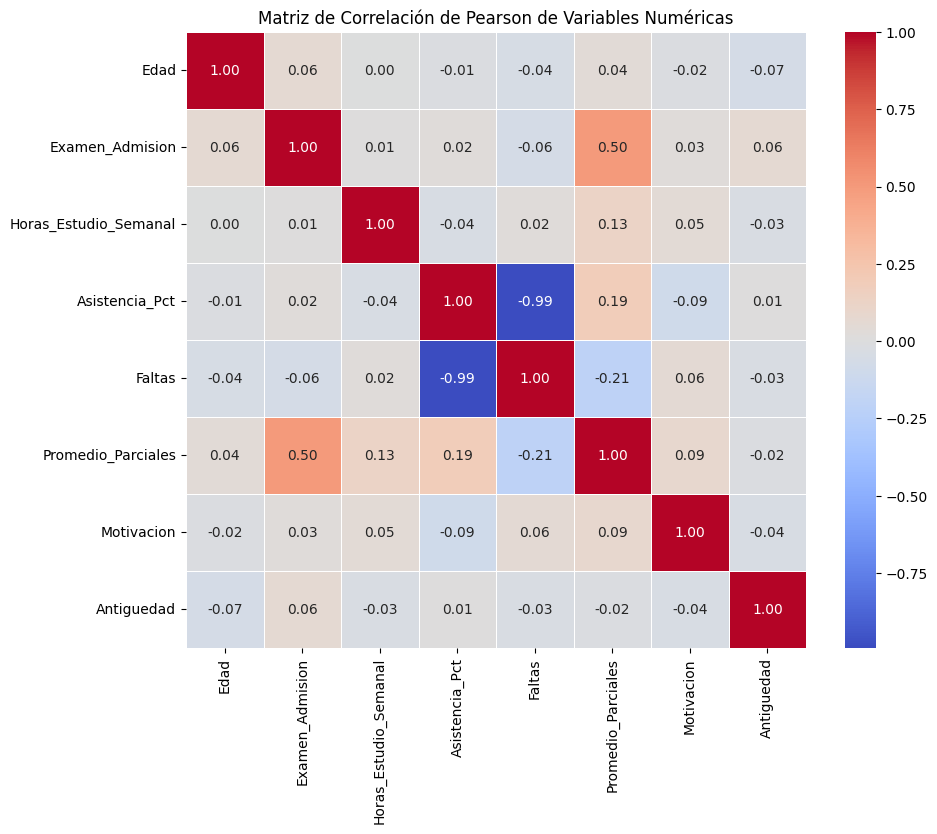

In [20]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Pearson de Variables Numéricas')
plt.show()

In [21]:
display(corr_matrix)

,Edad,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Faltas,Promedio_Parciales,Motivacion,Antiguedad
Edad,1.000000,0.061446,0.002414,-0.012563,-0.044644,0.038212,-0.018023,-0.065151
Examen_Admision,0.061446,1.000000,0.010983,0.019833,-0.062955,0.499417,0.025881,0.064694
Horas_Estudio_Semanal,0.002414,0.010983,1.000000,-0.036165,0.023336,0.126404,0.050592,-0.029265
Asistencia_Pct,-0.012563,0.019833,-0.036165,1.000000,-0.992026,0.187006,-0.090813,0.007779
Faltas,-0.044644,-0.062955,0.023336,-0.992026,1.000000,-0.211019,0.057729,-0.029022
Promedio_Parciales,0.038212,0.499417,0.126404,0.187006,-0.211019,1.000000,0.089275,-0.017222
Motivacion,-0.018023,0.025881,0.050592,-0.090813,0.057729,0.089275,1.000000,-0.036910
Antiguedad,-0.065151,0.064694,-0.029265,0.007779,-0.029022,-0.017222,-0.036910,1.000000


### Eliminación variable redundante

Según la matriz de correlación, `Faltas` está altamente correlacionada con otra variable, por lo que se elimina.

In [22]:
df.drop(columns=['Faltas'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Edad                   407 non-null    int64   
 1   Estilo_Aprendizaje     390 non-null    category
 2   Carrera                407 non-null    category
 3   Examen_Admision        370 non-null    float64 
 4   Horas_Estudio_Semanal  364 non-null    float64 
 5   Asistencia_Pct         371 non-null    float64 
 6   Promedio_Parciales     379 non-null    float64 
 7   Motivacion             407 non-null    int64   
 8   Aprobo                 407 non-null    category
 9   Antiguedad             407 non-null    float64 
dtypes: category(3), float64(5), int64(2)
memory usage: 24.4 KB


## Reporte de perfilado de datos

Se genera un reporte HTML completo con `ydata-profiling` (distribuciones, valores nulos, duplicados, correlaciones, etc.).

In [23]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Reporte de Perfilado de Datos de Aprobación de Curso')
profile.to_file('reporte_perfilado_curso.html')
print("Reporte guardado como: 'reporte_perfilado_curso.html'")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 49.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte guardado como: 'reporte_perfilado_curso.html'


## Análisis de variables categóricas

### Valores únicos por variable

In [25]:
categorical_cols = df.select_dtypes(include=['category']).columns

for col in categorical_cols:
    display(df[col].value_counts())

,count
Estilo_Aprendizaje,
visual,91
sensorial,70
secuencial,56
activo,41
equilibrio,39
verbal,37
intuitivo,32
reflexivo,24


,count
Carrera,
Ingenieria,82
Administracion,45
Derecho,45
Educacion,45
Psicologia,44
Economia,43
Artes,39
Sistemas,39
Medicina,25


,count
Aprobo,
no,297
si,110


### Comparación de `Carrera` con la aprobación

Tabla de contingencia Carrera vs Aprobo:


Aprobo,no,si
Carrera,,
Administracion,42,3
Artes,37,2
Derecho,43,2
Economia,32,11
Educacion,44,1
Ingenieria,15,67
Medicina,17,8
Psicologia,42,2
Sistemas,25,14



Proporción de aprobación por carrera:


Aprobo,no,si
Carrera,,
Administracion,0.933333,0.066667
Artes,0.948718,0.051282
Derecho,0.955556,0.044444
Economia,0.744186,0.255814
Educacion,0.977778,0.022222
Ingenieria,0.182927,0.817073
Medicina,0.680000,0.320000
Psicologia,0.954545,0.045455
Sistemas,0.641026,0.358974


<Figure size 1200x600 with 0 Axes>

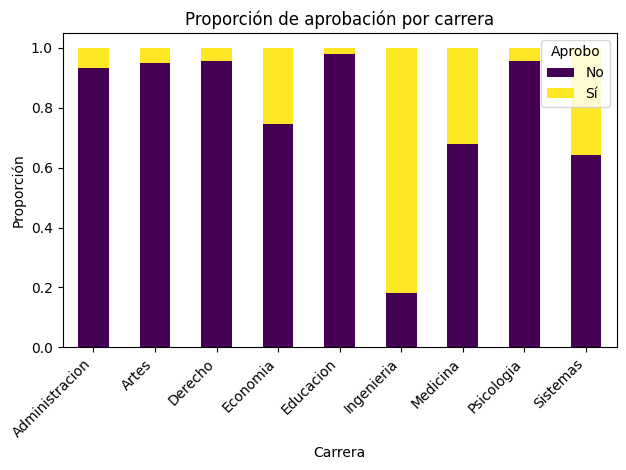

In [27]:
crosstab = pd.crosstab(df['Carrera'], df['Aprobo'])
print('Tabla de contingencia Carrera vs Aprobo:')
display(crosstab)

crosstab_pct = pd.crosstab(df['Carrera'], df['Aprobo'], normalize='index')
print('\nProporción de aprobación por carrera:')
display(crosstab_pct)

plt.figure(figsize=(12, 6))
crosstab_pct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Proporción de aprobación por carrera')
plt.xlabel('Carrera')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Aprobo', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

### Prueba de independecia Chi-Cuadrado

Se contrasta si existe independencia entre cada variable categórica y `Aprobo` (HO: son independientes). Un **p-valor < 0.05** indica que la variable está asociada con la aprobación.

In [30]:
for col in df.select_dtypes(include=['category']).columns:
    if col != 'Aprobo':
        table = pd.crosstab(df[col], df['Aprobo'])
        chi2, p, dof, expected = chi2_contingency(table)
        print(f'{col}: chi2 = {chi2:.4f} | p-valor = {p:.4f}')

Estilo_Aprendizaje: chi2 = 4.0579 | p-valor = 0.7731
Carrera: chi2 = 182.1193 | p-valor = 0.0000


### Eliminación de `Estilo_Aprendizaje`

Según los resultados anteriores, esta variable no muestra una asociación relevante con el objetivo.

In [31]:
df.drop(columns=['Estilo_Aprendizaje'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Edad                   407 non-null    int64   
 1   Carrera                407 non-null    category
 2   Examen_Admision        370 non-null    float64 
 3   Horas_Estudio_Semanal  364 non-null    float64 
 4   Asistencia_Pct         371 non-null    float64 
 5   Promedio_Parciales     379 non-null    float64 
 6   Motivacion             407 non-null    int64   
 7   Aprobo                 407 non-null    category
 8   Antiguedad             407 non-null    float64 
dtypes: category(2), float64(5), int64(2)
memory usage: 23.7 KB


## Codificación de variables

- **One-Hot Encoding** sobre `Carrera` (variable nominal).
- **Label Encoding** sobre `Aprobo` (`No`=0, `Si`=1), la variable objetivo.

In [33]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

carrera_encoded = ohe.fit_transform(df[['Carrera']])
carrera_df = pd.DataFrame(carrera_encoded, columns=ohe.get_feature_names_out(['Carrera']))

df = pd.concat([df.reset_index(drop=True), carrera_df], axis=1)
df.drop(columns=['Carrera'], inplace=True)

le = LabelEncoder()
df['Aprobo_encoded'] = le.fit_transform(df['Aprobo'])
df.drop(columns=['Aprobo'], inplace=True)

print('DataFrame después de la codificación:')
df.info()
df.head()

DataFrame después de la codificación:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    407 non-null    int64  
 1   Examen_Admision         370 non-null    float64
 2   Horas_Estudio_Semanal   364 non-null    float64
 3   Asistencia_Pct          371 non-null    float64
 4   Promedio_Parciales      379 non-null    float64
 5   Motivacion              407 non-null    int64  
 6   Antiguedad              407 non-null    float64
 7   Carrera_Administracion  407 non-null    float64
 8   Carrera_Artes           407 non-null    float64
 9   Carrera_Derecho         407 non-null    float64
 10  Carrera_Economia        407 non-null    float64
 11  Carrera_Educacion       407 non-null    float64
 12  Carrera_Ingenieria      407 non-null    float64
 13  Carrera_Medicina        407 non-null    float64
 14  Carr

,Edad,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Promedio_Parciales,Motivacion,Antiguedad,Carrera_Administracion,Carrera_Artes,Carrera_Derecho,Carrera_Economia,Carrera_Educacion,Carrera_Ingenieria,Carrera_Medicina,Carrera_Psicologia,Carrera_Sistemas,Aprobo_encoded
0,20,2.66,20.6,89.7,2.25,7,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,27,3.87,6.1,65.2,2.83,6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0,4.23,6.5,81.9,3.30,0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,19,4.07,15.6,88.3,NaN,4,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,25,3.01,8.1,82.2,2.24,8,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Tratamiento de valores atípicos

Primero se visualiza la distribución de cada variable numérica con diagramas de caja y bigotes.

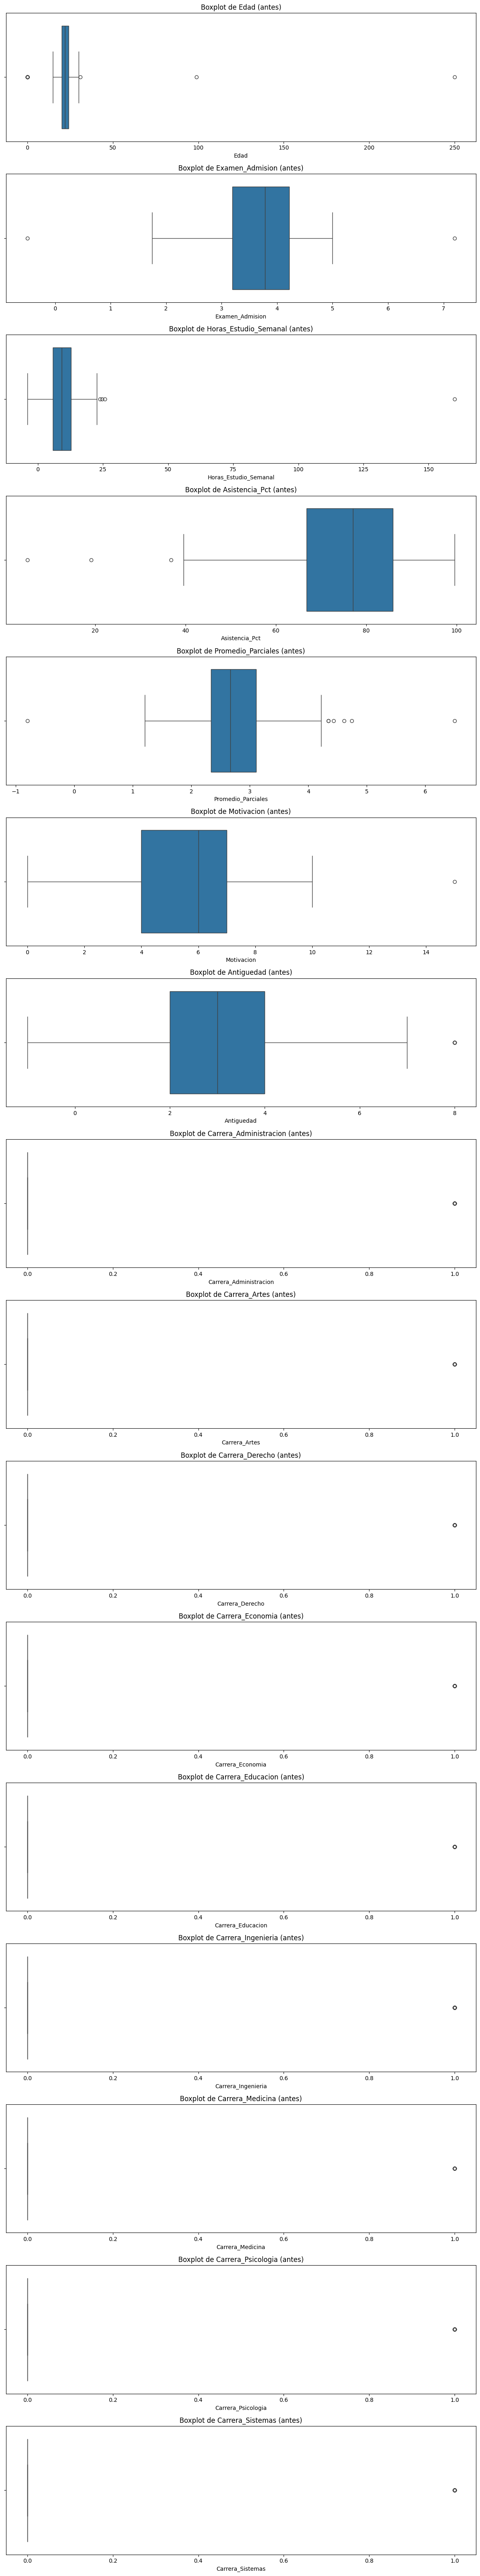

In [34]:
numerical_cols = df.select_dtypes(include=['number']).columns.drop('Aprobo_encoded')

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 4 * len(numerical_cols)))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot de {col} (antes)')
plt.tight_layout()
plt.show()

Los valores atípicos (fuera de los límites del rango intercuartílico, IQR) se convierten en `NaN` para tratarlos posteriormente con imputación.

In [35]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = pd.NA

print('Valores atípicos convertidos a nulos (excluyendo Aprobo_encoded).')
df.info()

Valores atípicos convertidos a nulos (excluyendo Aprobo_encoded).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    388 non-null    float64
 1   Examen_Admision         368 non-null    float64
 2   Horas_Estudio_Semanal   360 non-null    float64
 3   Asistencia_Pct          368 non-null    float64
 4   Promedio_Parciales      372 non-null    float64
 5   Motivacion              406 non-null    float64
 6   Antiguedad              401 non-null    float64
 7   Carrera_Administracion  362 non-null    float64
 8   Carrera_Artes           368 non-null    float64
 9   Carrera_Derecho         362 non-null    float64
 10  Carrera_Economia        364 non-null    float64
 11  Carrera_Educacion       362 non-null    float64
 12  Carrera_Ingenieria      325 non-null    float64
 13  Carrera_Medicina        382 n

### Boxplots después del tratamiento

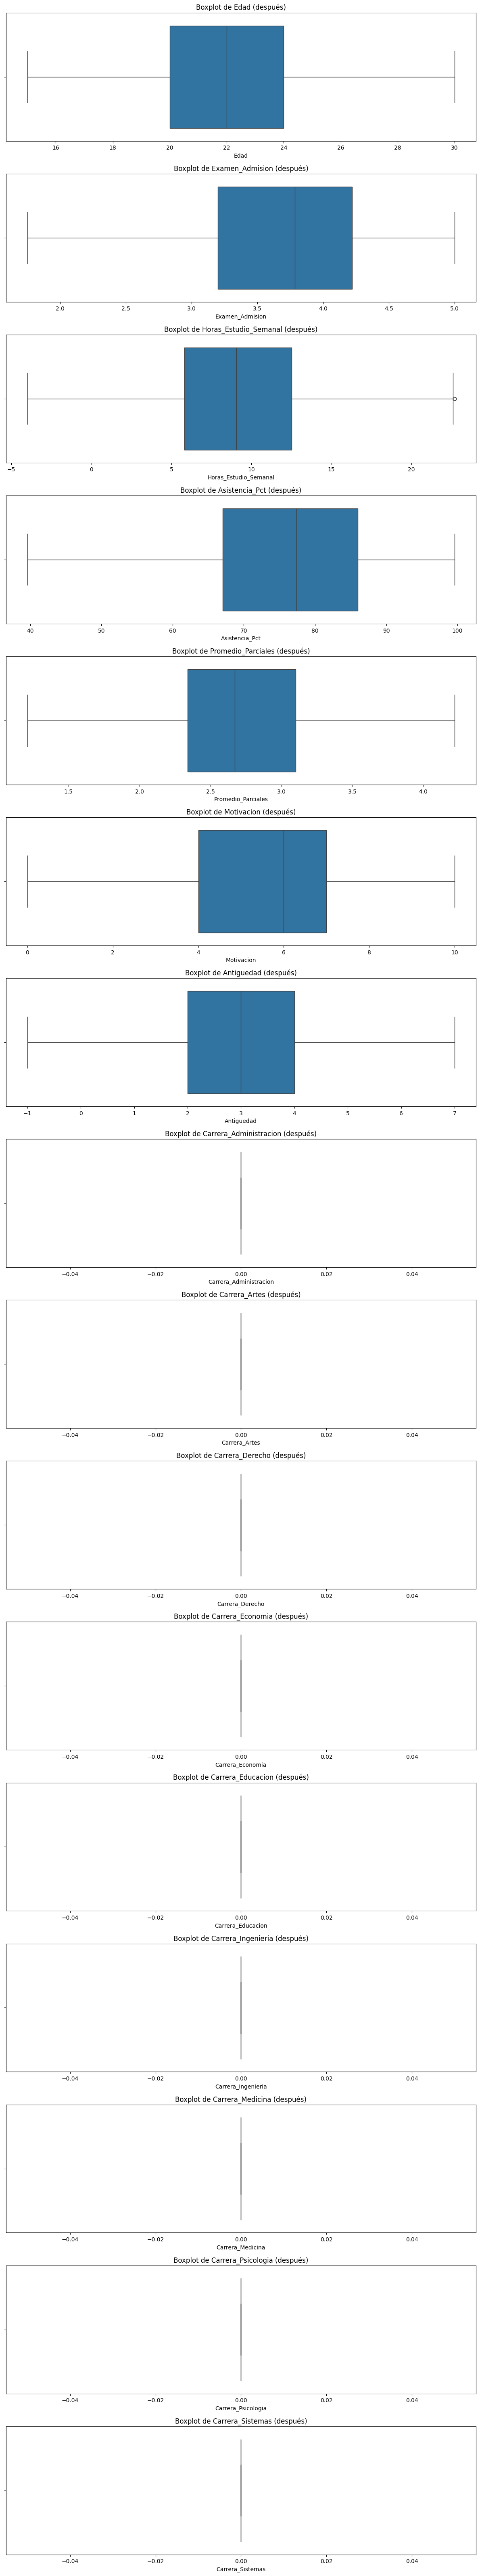

In [36]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 4 * len(numerical_cols)))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot de {col} (después)')
plt.tight_layout()
plt.show()

## Imputación de valores nulos con KNNImputer

Los `NaN` generados por los valores atípicos se imputan con **K-Nearest Neighbors**

In [37]:
imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# KNNImputer devuelve floats: se restaura el tipo entero en Edad
df['Edad'] = df['Edad'].round().astype('Int64')

print('Valores nulos imputados con KNNImputer.')
df.info()
display(df.head())

Valores nulos imputados con KNNImputer.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    407 non-null    Int64  
 1   Examen_Admision         407 non-null    float64
 2   Horas_Estudio_Semanal   407 non-null    float64
 3   Asistencia_Pct          407 non-null    float64
 4   Promedio_Parciales      407 non-null    float64
 5   Motivacion              407 non-null    float64
 6   Antiguedad              407 non-null    float64
 7   Carrera_Administracion  407 non-null    float64
 8   Carrera_Artes           407 non-null    float64
 9   Carrera_Derecho         407 non-null    float64
 10  Carrera_Economia        407 non-null    float64
 11  Carrera_Educacion       407 non-null    float64
 12  Carrera_Ingenieria      407 non-null    float64
 13  Carrera_Medicina        407 non-null    float64
 14  Ca

,Edad,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Promedio_Parciales,Motivacion,Antiguedad,Carrera_Administracion,Carrera_Artes,Carrera_Derecho,Carrera_Economia,Carrera_Educacion,Carrera_Ingenieria,Carrera_Medicina,Carrera_Psicologia,Carrera_Sistemas,Aprobo_encoded
0,20,2.66,20.6,89.7,2.250,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,27,3.87,6.1,65.2,2.830,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,24,4.23,6.5,81.9,3.300,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,19,4.07,15.6,88.3,2.734,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,25,3.01,8.1,82.2,2.240,8.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Escalado de variables numéricas (MinMaxScaler)

Se escala cada variable numérica al rango [0, 1], excluyendo la variable objetivo.

In [38]:
numerical_cols_to_scale = df.select_dtypes(include=['float64', 'int64', 'Int64']).columns.drop('Aprobo_encoded')

scaler = MinMaxScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print('DataFrame después del escalado Min-Max:')
df.info()
display(df.head())

DataFrame después del escalado Min-Max:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    407 non-null    float64
 1   Examen_Admision         407 non-null    float64
 2   Horas_Estudio_Semanal   407 non-null    float64
 3   Asistencia_Pct          407 non-null    float64
 4   Promedio_Parciales      407 non-null    float64
 5   Motivacion              407 non-null    float64
 6   Antiguedad              407 non-null    float64
 7   Carrera_Administracion  407 non-null    float64
 8   Carrera_Artes           407 non-null    float64
 9   Carrera_Derecho         407 non-null    float64
 10  Carrera_Economia        407 non-null    float64
 11  Carrera_Educacion       407 non-null    float64
 12  Carrera_Ingenieria      407 non-null    float64
 13  Carrera_Medicina        407 non-null    float64
 14  Ca

,Edad,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Promedio_Parciales,Motivacion,Antiguedad,Carrera_Administracion,Carrera_Artes,Carrera_Derecho,Carrera_Economia,Carrera_Educacion,Carrera_Ingenieria,Carrera_Medicina,Carrera_Psicologia,Carrera_Sistemas,Aprobo_encoded
0,0.333333,0.280000,0.921348,0.835000,0.345515,0.7,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.800000,0.652308,0.378277,0.426667,0.538206,0.6,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.600000,0.763077,0.393258,0.705000,0.694352,0.0,0.750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.266667,0.713846,0.734082,0.811667,0.506312,0.4,0.625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.666667,0.387692,0.453184,0.710000,0.342193,0.8,0.625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Balanceo de clases (undersampling)

La variable objetivo puede estar desbalanceada. Se aplica RandomUnderSampler de imblearn para igualar el número de muestras por clase y se grafica antes/después.

Distribución de la clase ANTES del balanceo:


,count
Aprobo_encoded,
0,297
1,110


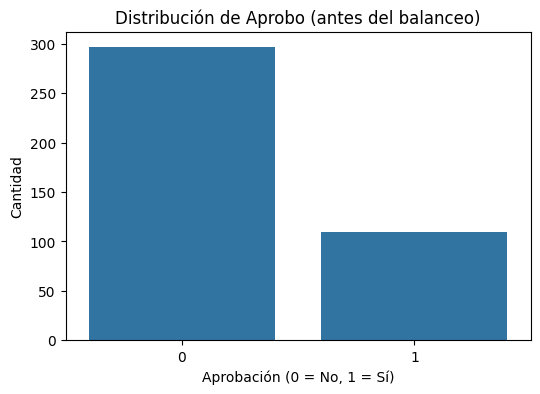

Distribución de la clase DESPUÉS del balanceo:


,count
Aprobo_encoded,
0,110
1,110


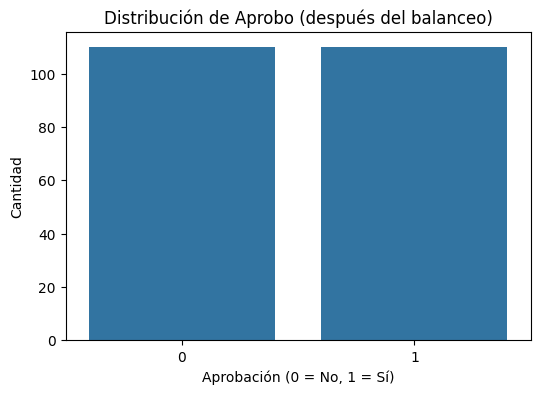


DataFrame actualizado después del balanceo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    220 non-null    float64
 1   Examen_Admision         220 non-null    float64
 2   Horas_Estudio_Semanal   220 non-null    float64
 3   Asistencia_Pct          220 non-null    float64
 4   Promedio_Parciales      220 non-null    float64
 5   Motivacion              220 non-null    float64
 6   Antiguedad              220 non-null    float64
 7   Carrera_Administracion  220 non-null    float64
 8   Carrera_Artes           220 non-null    float64
 9   Carrera_Derecho         220 non-null    float64
 10  Carrera_Economia        220 non-null    float64
 11  Carrera_Educacion       220 non-null    float64
 12  Carrera_Ingenieria      220 non-null    float64
 13  Carrera_Medicina        220 non-null    float64
 1

,Edad,Examen_Admision,Horas_Estudio_Semanal,Asistencia_Pct,Promedio_Parciales,Motivacion,Antiguedad,Carrera_Administracion,Carrera_Artes,Carrera_Derecho,Carrera_Economia,Carrera_Educacion,Carrera_Ingenieria,Carrera_Medicina,Carrera_Psicologia,Carrera_Sistemas,Aprobo_encoded
0,0.600000,0.901538,0.838951,0.566667,0.860465,0.2,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.400000,0.286154,0.554307,0.416667,0.481728,0.0,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.866667,0.763077,0.419476,0.465000,0.730897,0.7,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.266667,0.606154,0.786517,0.646667,0.581395,0.4,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.400000,0.523077,0.329588,0.625000,0.262458,0.5,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [39]:
from imblearn.under_sampling import RandomUnderSampler

X = df.drop('Aprobo_encoded', axis=1)
y = df['Aprobo_encoded']

print('Distribución de la clase ANTES del balanceo:')
display(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribución de Aprobo (antes del balanceo)')
plt.xlabel('Aprobación (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

print('Distribución de la clase DESPUÉS del balanceo:')
display(y_resampled.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled)
plt.title('Distribución de Aprobo (después del balanceo)')
plt.xlabel('Aprobación (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

df = pd.concat([X_resampled, y_resampled], axis=1).reset_index(drop=True)
print('\nDataFrame actualizado después del balanceo:')
df.info()
df.head()

## Reducción de dimensionalidad (PCA)

Se aplica Análisis de Componentes Principales sobre las características (excluyendo el objetivo) y luego se vuelve a integrar Aprobo_encoded al dataset reducido.

Varianza explicada por componente:
Componente 1: 0.2561 (25.61%)
Componente 2: 0.2176 (21.76%)
Componente 3: 0.1658 (16.58%)
Componente 4: 0.1334 (13.34%)
Componente 5: 0.1039 (10.39%)
Componente 6: 0.0895 (8.95%)
Componente 7: 0.0337 (3.37%)
Componente 8: 0.0000 (0.00%)
Componente 9: 0.0000 (0.00%)
Componente 10: 0.0000 (0.00%)
Componente 11: 0.0000 (0.00%)
Componente 12: 0.0000 (0.00%)
Componente 13: 0.0000 (0.00%)
Componente 14: 0.0000 (0.00%)
Componente 15: 0.0000 (0.00%)
Componente 16: 0.0000 (0.00%)


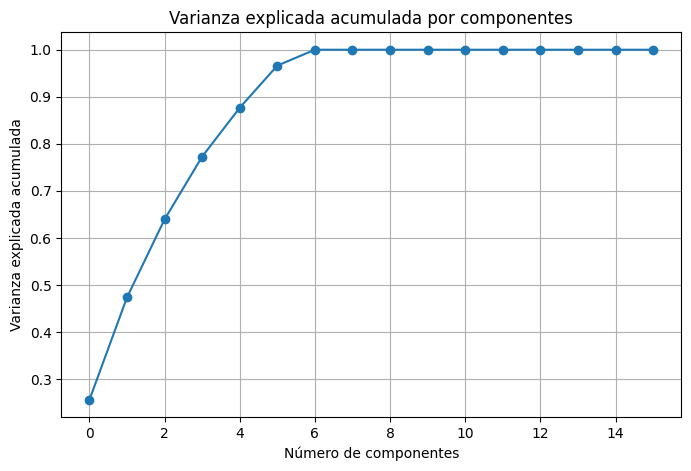

In [41]:
X = df.drop('Aprobo_encoded', axis=1)
y = df['Aprobo_encoded']

pca = PCA()
X_pca = pca.fit_transform(X)

print('Varianza explicada por componente:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'Componente {i+1}: {var:.4f} ({var*100:.2f}%)')

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por componentes')
plt.grid(True)
plt.show()

### Dataset final reducido

Se elige un número de componentes que conserve buena parte de la varianza y se integra el objetivo

In [43]:
n_components = 3
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X)

pca_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_reduced, columns=pca_cols)
df_pca['Aprobo_encoded'] = y.reset_index(drop=True)

df = df_pca.copy()
print('DataFrame final después de PCA:')
df_pca.info()
display(df_pca.head())

DataFrame final después de PCA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PC1             220 non-null    float64
 1   PC2             220 non-null    float64
 2   PC3             220 non-null    float64
 3   Aprobo_encoded  220 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 7.0 KB


,PC1,PC2,PC3,Aprobo_encoded
0,-0.195237,0.531600,-0.130521,0
1,-0.559958,-0.176888,-0.231690,0
2,0.197990,0.152521,-0.038301,0
3,-0.116665,0.116939,-0.396865,0
4,-0.177428,-0.288351,0.026382,0
